# Clase complementaria 2 — Hechos estilizados de las redes sociales

**MODELOS DE INTERACCIONES SOCIALES — ECON 64597, Sección 1**
Universidad de los Andes · Facultad de Economía · 2026-2
Alvaro J. Riascos Villegas · Gabriela Zamora

**Semana 33 · Clase 2**

**Lecturas que acompaña esta sesión**
- [J] Jackson (2018), cap. 2 — *Representing and Measuring Networks*
- [EK] Easley & Kleinberg (2010), cap. 3 — *Strong and Weak Ties*
- [EK] cap. 4 — *Networks in Their Surrounding Contexts*
- [EK] cap. 5 — *Positive and Negative Relationships*

---

## Qué es este notebook

Este **no** es un taller evaluado. Es el material computacional de la clase: cada
concepto teórico de las lecturas aparece aquí acompañado de una implementación
mínima y de un ejemplo numérico que se puede ejecutar y modificar en vivo.

La idea es que sirva para tres cosas:

1. **Ver** los objetos de los que habla la teoría. Un "puente local" o un "triángulo
   desbalanceado" son mucho más concretos cuando uno los cuenta en una red real.
2. **Comprobar** los teoremas. Varios resultados de [EK] se enuncian sin demostración
   formal; aquí se verifican numéricamente, que es una forma legítima de entenderlos
   antes de demostrarlos.
3. **Servir de plantilla**. El código está escrito para ser copiado y adaptado a los
   talleres y al proyecto final.

El notebook es **autocontenido**: todos los datos se generan internamente con semilla
fija. No requiere descargas ni conexión a internet.

## Mapa de la sesión

| Sección | Concepto | Lectura |
|---|---|---|
| 1 | Representación: matriz de adyacencia, grados, caminos | [J] §2.1 |
| 2 | Medir clustering: dos definiciones que no coinciden | [J] §2.2.3 |
| 3 | Centralidad: cuatro respuestas a "quién es importante" | [J] §2.2.4 |
| 4 | Cierre triádico, solapamiento y puentes locales | [EK] §3.1–3.2 |
| 5 | La propiedad de cierre triádico fuerte y su teorema | [EK] §3.1 |
| 6 | El experimento de Onnela: percolación por fuerza de lazo | [EK] §3.3 |
| 7 | Homofilia y su *benchmark* aleatorio | [EK] §4.1 |
| 8 | Redes de afiliación y cierre focal | [EK] §4.3 |
| 9 | Balance estructural y el teorema de las facciones | [EK] §5.1–5.3 |
| 10 | Síntesis y qué sigue | — |


---
## 0. Preparación

Cuatro librerías. `networkx` es el estándar del curso: cubre todo lo que necesitamos
y su API se lee casi como la notación de [EK].


In [1]:
import itertools
from collections import deque

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEMILLA = 64597
np.set_printoptions(linewidth=120)
pd.set_option("display.width", 120)

print("numpy", np.__version__, "| pandas", pd.__version__, "| networkx", nx.__version__)

numpy 2.4.6 | pandas 3.0.3 | networkx 3.6.1


### La red que usaremos como ejemplo corrido

Una red sintética de 60 estudiantes de dos programas, generada con un **modelo de
bloques estocásticos** (*stochastic block model*): la probabilidad de que dos
estudiantes sean amigos es alta dentro del mismo programa (0.14 y 0.16) y baja entre
programas (0.02).

Además le asignamos a cada lazo una **fuerza** entre 1 y 6. La generamos como
`1 + (número de amigos en común) + ruido`, replicando a propósito el patrón que
Onnela et al. (2007) encuentran en datos reales de telefonía móvil. Volveremos sobre
la circularidad de este supuesto en la sección 6 — es importante y hay que tenerla
presente desde ya.


In [2]:
# rng = "generador de números aleatorios". Le pasamos SEMILLA para que el azar
# sea REPRODUCIBLE: cada vez que corran el código, obtienen los mismos resultados.
rng = np.random.default_rng(SEMILLA)

# Creamos la red con un "modelo de bloques estocásticos":
#   [35, 25]  -> dos grupos: 35 personas en el primero, 25 en el segundo (60 en total)
#   [[0.14, 0.02],
#    [0.02, 0.16]] -> matriz de PROBABILIDADES de amistad (la elegimos nosotros):
#        0.14 = prob. de amistad DENTRO del grupo 1
#        0.16 = prob. de amistad DENTRO del grupo 2
#        0.02 = prob. de amistad ENTRE grupos (baja -> por eso quedan 2 comunidades)
#   seed=SEMILLA -> de nuevo, para que la red sea siempre la misma.
G = nx.stochastic_block_model([35, 25], [[0.14, 0.02], [0.02, 0.16]], seed=SEMILLA)

# Atributos de nodo
# Le "pegamos" a cada persona (nodo) información extra: su programa y su ciudad.

# Los primeros 35 nodos son de Economía y los siguientes 25 de Ingeniería.
# ["Economía"] * 35 crea una lista con "Economía" repetido 35 veces; luego se concatena.
programas = ["Economía"] * 35 + ["Ingeniería"] * 25

# A cada uno de los 60 nodos le asignamos una ciudad AL AZAR, pero con probabilidades
# distintas: Bogotá 50%, Cali 20%, Medellín 20%, Barranquilla 10%.
# rng.choice(...) hace el sorteo; str(c) solo convierte cada resultado a texto.
ciudades = [str(c) for c in rng.choice(["Bogotá", "Cali", "Medellín", "Barranquilla"],
                                       size=60, p=[0.5, 0.2, 0.2, 0.1])]

# set_node_attributes guarda esos datos DENTRO del grafo, nodo por nodo.
# dict(enumerate(programas)) empareja: nodo 0 -> "Economía", nodo 1 -> "Economía", ...
nx.set_node_attributes(G, dict(enumerate(programas)), "programa")
nx.set_node_attributes(G, dict(enumerate(ciudades)), "ciudad")

# Fuerza de los lazos
# Ahora le damos a cada AMISTAD (arista) una "fuerza" y la clasificamos en fuerte/débil.

# Umbral de decisión: una amistad será "fuerte" si su fuerza es 4 o más.
UMBRAL_FUERTE = 4

# Recorremos todas las amistades (u, v son las dos personas de cada arista):
for u, v in G.edges():
    # Amigos en común de u y v:
    #   set(G[u]) = conjunto de amigos de u ; set(G[v]) = amigos de v
    #   el "&" es la INTERSECCIÓN (los que están en ambos) ; len(...) los cuenta.
    comunes = len(set(G[u]) & set(G[v]))

    # Fuerza = 1 + (amigos en común) + un poco de ruido aleatorio (0, 1 o 2).
    #   rng.integers(0, 3) devuelve un entero al azar en {0, 1, 2} (el 3 NO se incluye).
    #   int(...) asegura que quede como número entero.
    f = int(1 + comunes + rng.integers(0, 3))

    # Guardamos dentro de la arista dos datos nuevos:
    G[u][v]["fuerza"] = f                                    # el número de fuerza
    G[u][v]["tipo"] = "fuerte" if f >= UMBRAL_FUERTE else "debil"  # su etiqueta

# Imprimimos un resumen del grafo (nombre, número de nodos y de aristas).
print(G)

# Contamos cuántas amistades quedaron "fuertes" y cuántas "débiles".
#   sum(1 for ... if condición) suma un 1 por cada arista que cumple la condición
#   (es una forma compacta de "contar cuántas cumplen X").
print("Lazos fuertes:", sum(1 for u, v in G.edges() if G[u][v]["tipo"] == "fuerte"),
      "| débiles:", sum(1 for u, v in G.edges() if G[u][v]["tipo"] == "debil"))

Graph named 'stochastic_block_model' with 60 nodes and 152 edges
Lazos fuertes: 26 | débiles: 126


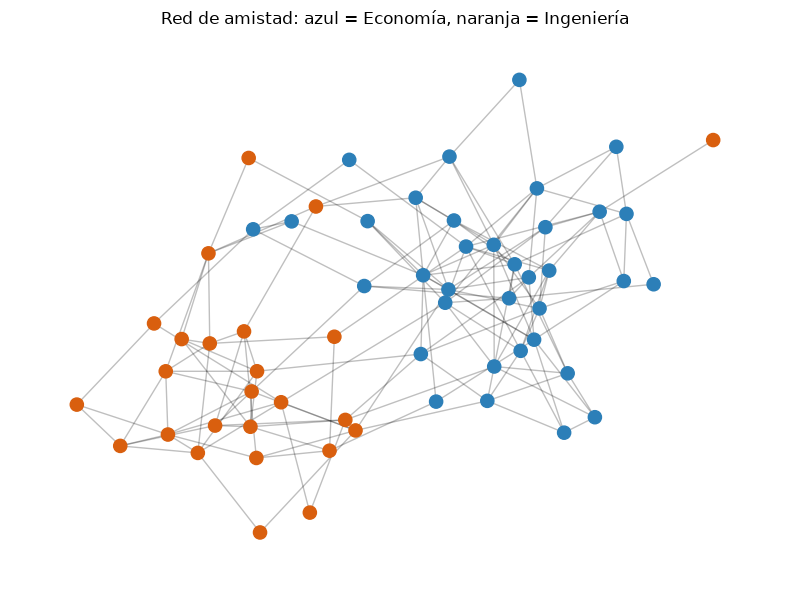

In [3]:
# Una mirada rápida a la red completa
pos = nx.spring_layout(G, seed=SEMILLA)
colores = ["#2c7fb8" if G.nodes[v]["programa"] == "Economía" else "#d95f0e" for v in G]

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, alpha=0.25, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=90, ax=ax)
ax.set_title("Red de amistad: azul = Economía, naranja = Ingeniería")
ax.axis("off")
fig.tight_layout()
plt.show()

Los dos bloques ya se ven a simple vista. Todo lo que sigue es un intento de
*medir* lo que el ojo detecta aquí, y de detectar lo que el ojo no ve.


---
# 1. Representación de una red

**Lectura: [J] §2.1**

Un grafo no dirigido $g$ sobre $N = \{1,\dots,n\}$ se representa por su **matriz de
adyacencia** $A$, con

$$A_{ij} = \begin{cases} 1 & \text{si } \{i,j\} \in g \\ 0 & \text{si no}\end{cases}$$

Para grafos no dirigidos y simples, $A = A^{\top}$ y $A_{ii} = 0$.

Tres cantidades básicas se leen directamente de $A$:

| Concepto | Fórmula |
|---|---|
| Grado de $i$ | $d_i = \sum_j A_{ij}$ |
| Número de aristas | $m = \tfrac{1}{2}\sum_i d_i$ (*handshake lemma*) |
| Densidad | $\dfrac{2m}{n(n-1)}$ |


In [4]:
# Convertimos el grafo G en su MATRIZ de adyacencia (numpy).
#   nodelist=sorted(...) -> fija el orden de filas/columnas (0,1,2,...) para que sea reproducible.
#   .astype(int) -> deja las casillas como enteros 0/1 (no decimales).
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes())).astype(int)

n = A.shape[0]        # n = número de nodos = número de filas de la matriz
d = A.sum(axis=1)     # d = grado de cada nodo = suma de cada FILA (cuántos amigos tiene)
m = d.sum() // 2      # m = número de aristas = (suma de grados) / 2  [cada arista se cuenta 2 veces]

print("Matriz de adyacencia, esquina superior 8x8:")
print(A[:8, :8])      # muestra solo las primeras 8 filas y 8 columnas (la matriz completa es 60x60)
print()

# Resumen: nodos, aristas y densidad = 2m / (n(n-1)) = fracción de amistades posibles que existen.
print(f"n = {n} | m = {m} | densidad = {2*m/(n*(n-1)):.4f}")

# Chequeos de que la matriz está bien construida:
#   np.array_equal(A, A.T) -> ¿es igual a su transpuesta? (debe ser simétrica: grafo no dirigido)
#   np.trace(A) == 0       -> ¿la diagonal suma 0? (nadie es amigo de sí mismo, sin auto-lazos)
print("Simétrica:", np.array_equal(A, A.T), "| diagonal nula:", np.trace(A) == 0)

# Verifica el lema del apretón de manos: la suma de los grados debe ser igual a 2m.
print("Handshake lemma:", d.sum(), "==", 2 * m)

Matriz de adyacencia, esquina superior 8x8:
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1]
 [0 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 1 0 1 1 0 0 0]]

n = 60 | m = 152 | densidad = 0.0859
Simétrica: True | diagonal nula: True
Handshake lemma: 304 == 304


### La potencia de la matriz cuenta caminatas

Este es el resultado que hace que valga la pena trabajar con $A$ y no solo con listas
de vecinos:

> **Proposición.** $(A^k)_{ij}$ es el número de **caminatas** (*walks*) de longitud
> exactamente $k$ que van de $i$ a $j$.

La intuición es inductiva: una caminata de longitud $k$ de $i$ a $j$ es una caminata
de longitud $k-1$ de $i$ a algún $\ell$, seguida de la arista $\{\ell, j\}$. Sumar
sobre todos los $\ell$ posibles es exactamente lo que hace el producto matricial.

Dos consecuencias útiles:

- $(A^2)_{ii} = d_i$, porque una caminata de longitud 2 que vuelve a $i$ es "salir a
  un vecino y regresar".
- $(A^2)_{ij}$ para $i \neq j$ es el **número de vecinos comunes** de $i$ y $j$.
- $\operatorname{tr}(A^3) = 6 \times \#\text{triángulos}$: cada triángulo se cuenta
  una vez por cada uno de sus 3 vértices, y en cada vértice en 2 direcciones.


In [5]:
# Potencias de la matriz (multiplicación de matrices, con @, NO casilla por casilla):
A2 = A @ A     # A^2 : (A^2)_ij = # de caminatas de longitud 2 de i a j
A3 = A2 @ A    # A^3 : caminatas de longitud 3

# La diagonal de A^2 debe ser el vector de grados:
#   un camino de longitud 2 que sale de i y vuelve a i = "ir a un vecino y regresar",
#   y hay tantos como vecinos tenga i. Por eso (A^2)_ii = d_i.
print("(A^2)_ii == grado:", np.array_equal(np.diag(A2), d))

# Buscamos el par de nodos con MÁS vecinos en común (el mayor valor fuera de la diagonal).
#   A2 - np.diag(np.diag(A2)) -> pone la diagonal en 0 para que no la elija (la diagonal son los grados).
#   np.argmax(...) -> posición del valor máximo (como si la matriz fuera una lista larga).
#   np.unravel_index(..., A2.shape) -> traduce esa posición a coordenadas (fila i, columna j).
i, j = np.unravel_index(np.argmax(A2 - np.diag(np.diag(A2))), A2.shape)

# Mostramos ese valor y lo VERIFICAMOS a mano:
#   (A^2)_ij = número de vecinos comunes de i y j (fuera de la diagonal).
#   set(G[i]) & set(G[j]) = intersección de sus amigos ; len(...) los cuenta -> debe coincidir.
print(f"Vecinos comunes de {i} y {j}: (A^2)_ij = {A2[i, j]}"
      f" | verificación: {len(set(G[i]) & set(G[j]))}")

# Número de triángulos con la traza de A^3:
#   tr(A^3) suma la diagonal (caminatas de longitud 3 que empiezan y terminan en el mismo nodo).
#   Cada triángulo se cuenta 6 veces (3 vértices de partida x 2 sentidos), por eso / 6.
triangulos = np.trace(A3) // 6
print("Triángulos vía tr(A^3)/6 :", triangulos)

# Comprobación con la librería: networkx cuenta cada triángulo 3 veces (uno por vértice), por eso / 3.
print("Triángulos vía networkx  :", sum(nx.triangles(G).values()) // 3)

(A^2)_ii == grado: True
Vecinos comunes de 15 y 27: (A^2)_ij = 4 | verificación: 4
Triángulos vía tr(A^3)/6 : 32
Triángulos vía networkx  : 32


> ⚠️ **Advertencia de implementación.** En NumPy, `A ** 3` eleva **cada entrada** al
> cubo, no la matriz. Como las entradas son 0 y 1, `A ** 3 == A` y la traza da 0.
> Para potencias matriciales: `A @ A @ A` o `np.linalg.matrix_power(A, 3)`.


In [6]:
print("A ** 3 (elemento a elemento) -> traza:", np.trace(A ** 3), "  <- ¡mal!")
print("np.linalg.matrix_power(A, 3)  -> traza:", np.trace(np.linalg.matrix_power(A, 3)))

A ** 3 (elemento a elemento) -> traza: 0   <- ¡mal!
np.linalg.matrix_power(A, 3)  -> traza: 192


---
# 2. Medir clustering: dos definiciones que no coinciden

**Lectura: [J] §2.2.3**

El *clustering* mide qué tan frecuente es que "los amigos de mis amigos sean también
mis amigos". Es la propiedad que distingue de manera más nítida a una red social de
un grafo aleatorio. Pero **hay dos formas estándar de medirlo y dan números
distintos**. Jackson es explícito en que esto se malinterpreta con frecuencia.

### Clustering global (transitividad)

Una razón agregada sobre toda la red:

$$Cl(g) = \frac{3 \times \#\text{triángulos}}{\#\text{tripletas conectadas}}
        = \frac{\operatorname{tr}(A^3)}{\sum_i d_i(d_i - 1)}$$

Una **tripleta conectada** centrada en $i$ es un par de vecinos de $i$; hay
$\binom{d_i}{2}$ de ellas. El numerador cuenta cuántas de esas tripletas están
efectivamente cerradas.

### Clustering promedio

Se calcula el clustering **local** de cada nodo,

$$Cl_i = \frac{\#\{\text{pares de vecinos de } i \text{ que son adyacentes}\}}{\binom{d_i}{2}}$$

y luego se promedia sobre nodos: $Cl^{avg}(g) = \frac{1}{n}\sum_i Cl_i$.

### Por qué difieren

El clustering global pondera cada nodo por su número de tripletas, es decir
aproximadamente por $d_i^2$: **los nodos de grado alto dominan**. El promedio le da a
cada nodo el mismo peso, y como los nodos de grado bajo tienden a tener $Cl_i$ más
extremo (con $d_i = 2$, $Cl_i$ solo puede ser 0 o 1), **los nodos periféricos
dominan**.


In [7]:
def clustering_global(A):
    """Clustering global (transitividad) desde la matriz de adyacencia."""
    # d = grado de cada nodo (suma de cada fila de la matriz).
    d = A.sum(axis=1)

    # Denominador = número de "triples conectados" (contados 2 veces).
    #   Cada nodo con grado d_i aporta d_i*(d_i - 1) triples ordenados.
    #   float(...) lo convierte a decimal para poder dividir sin problemas.
    denom = float(np.sum(d * (d - 1)))

    # Caso borde: si no hay ningún triple (red sin conexiones útiles),
    # evitamos dividir por cero y devolvemos 0.
    if denom == 0:
        return 0.0

    # Numerador = tr(A^3) = caminatas cerradas de longitud 3 = 6 x (# triángulos).
    #   Como el denominador también está "inflado" 2 veces, las escalas se cancelan
    #   y el cociente da exactamente la transitividad.  (¡ojo: matrix_power, no A**3!)
    return float(np.trace(np.linalg.matrix_power(A, 3)) / denom)


# Clustering LOCAL de cada nodo (con la librería): {nodo: valor}.
cl_local = nx.clustering(G)

# Grado de cada nodo, como diccionario {nodo: grado}.
grados = dict(G.degree())

# Grafo aleatorio de REFERENCIA (el "modelo nulo"):
#   gnm_random_graph(n, m) = red al azar con EXACTAMENTE los mismos n nodos y m aristas.
#   seed=SEMILLA -> reproducible. Sirve para responder "¿nuestro clustering es alto?".
ER = nx.gnm_random_graph(n, m, seed=SEMILLA)

# Comparamos nuestra fórmula contra la de la librería (deben coincidir):
print(f"Clustering global (nuestra fórmula) : {clustering_global(A):.4f}")
print(f"Clustering global (nx.transitivity) : {nx.transitivity(G):.4f}")
# Y mostramos las otras dos medidas de la red real:
print(f"Clustering promedio                 : {nx.average_clustering(G):.4f}")
print(f"Densidad de la red                  : {nx.density(G):.4f}")
print()

# Lo mismo para la red aleatoria: si la real tiene MUCHO más clustering
# que esta referencia, es señal de estructura real (comunidades), no azar.
print(f"Referencia G(n,m): global {nx.transitivity(ER):.4f} | "
      f"promedio {nx.average_clustering(ER):.4f} | densidad {nx.density(ER):.4f}")

Clustering global (nuestra fórmula) : 0.1320
Clustering global (nx.transitivity) : 0.1320
Clustering promedio                 : 0.1210
Densidad de la red                  : 0.0859

Referencia G(n,m): global 0.0663 | promedio 0.0694 | densidad 0.0859


**Lectura del resultado.** El punto de comparación correcto no es cero, sino la
densidad. En un grafo aleatorio, la probabilidad de que dos vecinos de $i$ estén
conectados es simplemente la densidad, así que clustering ≈ densidad. Nuestra red
tiene clustering global ≈ 0.13 contra densidad ≈ 0.086: hay **exceso de clustering**,
que es justamente el hecho estilizado. La red $G(n,m)$ de referencia confirma que el
exceso no es un artefacto del tamaño.


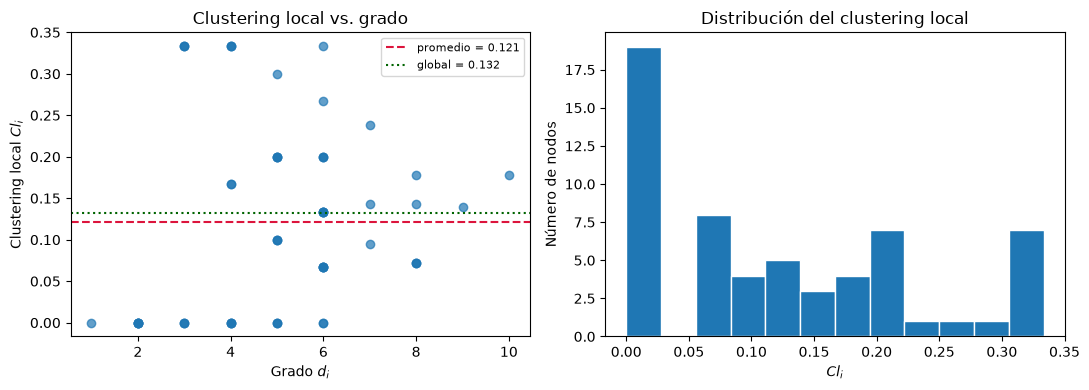

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter([grados[v] for v in G], [cl_local[v] for v in G], alpha=0.7)
ax[0].axhline(nx.average_clustering(G), color="crimson", ls="--",
              label=f"promedio = {nx.average_clustering(G):.3f}")
ax[0].axhline(nx.transitivity(G), color="darkgreen", ls=":",
              label=f"global = {nx.transitivity(G):.3f}")
ax[0].set_xlabel("Grado $d_i$")
ax[0].set_ylabel("Clustering local $Cl_i$")
ax[0].set_title("Clustering local vs. grado")
ax[0].legend(fontsize=8)

ax[1].hist([cl_local[v] for v in G], bins=12, edgecolor="white")
ax[1].set_xlabel("$Cl_i$")
ax[1].set_ylabel("Número de nodos")
ax[1].set_title("Distribución del clustering local")

fig.tight_layout()
plt.show()

El *scatter* muestra la dispersión que explica la discrepancia: los nodos de grado
bajo producen valores extremos de $Cl_i$ que el promedio recoge con todo su peso y el
global casi ignora.

### Un ejemplo mínimo donde las dos medidas divergen fuerte

Tomemos una "estrella con un triángulo": un centro conectado a muchos nodos, más
unos pocos triángulos pequeños en la periferia.


In [9]:
# Estrella de 10 hojas + 3 triángulos disjuntos pegados a la periferia
Ej = nx.star_graph(10)
sig = 11
for _ in range(3):
    Ej.add_edges_from([(sig, sig + 1), (sig + 1, sig + 2), (sig + 2, sig)])
    sig += 3

print(f"Clustering global   : {nx.transitivity(Ej):.4f}")
print(f"Clustering promedio : {nx.average_clustering(Ej):.4f}")
print("El centro de la estrella tiene Cl_i =", nx.clustering(Ej)[0],
      "y muchísimas tripletas abiertas.")

Clustering global   : 0.1667
Clustering promedio : 0.4500
El centro de la estrella tiene Cl_i = 0 y muchísimas tripletas abiertas.


> **Para discutir en clase.** Si un artículo reporta "clustering = 0.42" sin decir
> cuál de las dos medidas usó, ¿qué tan grave es? ¿En qué tipo de red esperarían que
> la diferencia sea mayor?


---
# 3. Centralidad: cuatro respuestas a la misma pregunta

**Lectura: [J] §2.2.4**

"¿Quién es importante en esta red?" no tiene una respuesta única, porque *importante*
significa cosas distintas según el proceso que nos interese.

| Medida | Qué mide | Proceso implícito |
|---|---|---|
| **Grado** | Cuántos vecinos directos | Contagio inmediato, popularidad |
| **Cercanía** (*closeness*) | Inverso de la distancia media al resto | Velocidad de difusión desde el nodo |
| **Intermediación** (*betweenness*) | Fracción de caminos más cortos que pasan por el nodo | Control de flujos, poder de intermediación |
| **Autovector** | Estar conectado a nodos que a su vez están bien conectados | Prestigio recursivo |

Formalmente, para la centralidad de autovector: $\lambda x = A x$, donde $x$ es el
autovector asociado al mayor autovalor $\lambda_{\max}$. La ecuación dice
$x_i = \frac{1}{\lambda}\sum_j A_{ij} x_j$: mi importancia es proporcional a la suma
de la importancia de mis vecinos.


In [10]:
centralidades = pd.DataFrame({
    "grado":          pd.Series(nx.degree_centrality(G)),
    "cercania":       pd.Series(nx.closeness_centrality(G)),
    "intermediacion": pd.Series(nx.betweenness_centrality(G)),
    "autovector":     pd.Series(nx.eigenvector_centrality(G, max_iter=1000)),
})

print("Correlaciones de Spearman entre medidas:")
print(centralidades.corr(method="spearman").round(3))
print()
print("Top 5 por intermediación:")
print(centralidades.nlargest(5, "intermediacion").round(4))
print()
print("Top 5 por grado:")
print(centralidades.nlargest(5, "grado").round(4))

Correlaciones de Spearman entre medidas:
                grado  cercania  intermediacion  autovector
grado           1.000     0.768           0.788       0.744
cercania        0.768     1.000           0.837       0.842
intermediacion  0.788     0.837           1.000       0.582
autovector      0.744     0.842           0.582       1.000

Top 5 por intermediación:
     grado  cercania  intermediacion  autovector
7   0.1356    0.4275          0.1065      0.1970
51  0.1017    0.3882          0.0905      0.0773
18  0.1356    0.4069          0.0896      0.1941
15  0.1525    0.4275          0.0849      0.2752
29  0.1695    0.4338          0.0805      0.2960

Top 5 por grado:
     grado  cercania  intermediacion  autovector
29  0.1695    0.4338          0.0805      0.2960
15  0.1525    0.4275          0.0849      0.2752
7   0.1356    0.4275          0.1065      0.1970
10  0.1356    0.4041          0.0664      0.2170
18  0.1356    0.4069          0.0896      0.1941


Las correlaciones son altas pero lejos de 1 — entre intermediación y autovector es
apenas 0.58. Los *rankings* **no** coinciden, y esa discrepancia es informativa: un
nodo con intermediación alta y autovector bajo es típicamente un **puente entre
comunidades** (conecta mucho, pero con gente que no está bien conectada entre sí).

### Katz–Bonacich: interpolando entre grado y autovector

[J] §2.2.4 presenta una familia que contiene a las anteriores como casos límite. Con
factor de atenuación $a$:

$$C^{B}(a) = (I - aA)^{-1} A \mathbf{1}$$

La expansión en serie hace transparente qué está midiendo:

$$(I - aA)^{-1} A \mathbf{1} = A\mathbf{1} + aA^{2}\mathbf{1} + a^{2}A^{3}\mathbf{1} + \cdots$$

es decir, **la suma de todas las caminatas que salen del nodo, descontando las de
longitud $k$ por $a^{k-1}$**. Con $a \to 0$ solo sobreviven las caminatas de longitud
1: recuperamos el grado. Con $a \to 1/\lambda_{\max}$ las caminatas largas pesan cada
vez más y nos acercamos al autovector.

La serie converge —y la inversa existe— solo si $a < 1/\lambda_{\max}(A)$. Esta
condición no es un tecnicismo: si se viola, `np.linalg.inv` **no falla**, simplemente
devuelve números sin sentido económico (centralidades negativas).


In [11]:
def bonacich(A, a):
    """Centralidad de Katz-Bonacich con factor de atenuación a."""
    lam = np.max(np.abs(np.linalg.eigvals(A).real))
    if a >= 1 / lam:
        raise ValueError(f"a debe ser menor que 1/lambda_max = {1/lam:.4f}")
    n = A.shape[0]
    return np.linalg.inv(np.eye(n) - a * A) @ A @ np.ones(n)


lam_max = np.max(np.abs(np.linalg.eigvals(A).real))
print(f"lambda_max = {lam_max:.4f}  ->  a debe ser < {1/lam_max:.4f}")

vec_grado = pd.Series(A.sum(axis=1))
vec_eig = pd.Series([nx.eigenvector_centrality(G, max_iter=1000)[v]
                     for v in sorted(G.nodes())])

filas = []
for a in [0.001, 0.01, 0.05, 0.10, 0.15, 0.165]:
    b = pd.Series(bonacich(A, a))
    filas.append({"a": a,
                  "corr_con_grado": b.corr(vec_grado, method="spearman"),
                  "corr_con_autovector": b.corr(vec_eig, method="spearman")})
print()
print(pd.DataFrame(filas).round(4).to_string(index=False))

lambda_max = 6.0308  ->  a debe ser < 0.1658

    a  corr_con_grado  corr_con_autovector
0.001          0.9825               0.8154
0.010          0.9825               0.8154
0.050          0.9825               0.8209
0.100          0.9556               0.8784
0.150          0.8225               0.9803
0.165          0.7552               0.9993


El patrón es exactamente el anunciado: la correlación con el grado cae monótonamente
(0.98 → 0.71) y la correlación con el autovector sube (0.82 → 0.99) a medida que $a$
se acerca al umbral. **El parámetro $a$ es una elección sustantiva**, no un detalle
computacional: dice qué tan lejos en la red uno cree que viajan los efectos que le
interesan.


In [12]:
# Qué pasa si se ignora la condición de convergencia
try:
    bonacich(A, 0.5)
except ValueError as e:
    print("La función protege el cálculo:", e)

malo = np.linalg.inv(np.eye(n) - 0.5 * A) @ A @ np.ones(n)
print("\nSin la protección, np.linalg.inv devuelve valores como:")
print(np.round(malo[:6], 2), " <- centralidades negativas, sin interpretación")

La función protege el cálculo: a debe ser menor que 1/lambda_max = 0.1658

Sin la protección, np.linalg.inv devuelve valores como:
[ 3.44 -5.48 -0.88 -4.42  4.84  1.05]  <- centralidades negativas, sin interpretación


---
# 4. Cierre triádico, solapamiento y puentes locales

**Lectura: [EK] §3.1–3.2**

El **cierre triádico** es la observación de que si $B$ y $C$ tienen un amigo común
$A$, aumenta la probabilidad de que $B$ y $C$ se conozcan. Es lo que produce el exceso
de clustering de la sección 2. Tres mecanismos lo explican ([EK] §3.1): oportunidad
(se encuentran), confianza (el amigo común avala) e incentivo de $A$ (reducir la
tensión de tener dos amigos que no se conocen).

Su contrapartida estructural es el **puente**. Un **puente** es una arista cuya
eliminación desconecta la red — algo rarísimo en redes reales. La versión útil es más
débil:

> Una arista $\{u,v\}$ es un **puente local** si $u$ y $v$ **no tienen ningún vecino
> en común**. Su ***span*** es la distancia entre $u$ y $v$ después de borrarla.

La medida continua correspondiente es el **solapamiento de vecindarios**:

$$O_{uv} = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|}$$

donde en ambos conjuntos se **excluyen $u$ y $v$ mismos**. Un puente local es
exactamente una arista con $O_{uv} = 0$.


In [13]:
def solapamiento(G, u, v):
    """Solapamiento de vecindarios de la arista {u,v}, excluyendo u y v."""
    a = set(G[u]) - {v}
    b = set(G[v]) - {u}
    union = a | b
    return len(a & b) / len(union) if union else 0.0


def es_puente_local(G, u, v):
    return G.has_edge(u, v) and solapamiento(G, u, v) == 0.0


def span(G, u, v):
    """Distancia entre u y v tras eliminar la arista {u,v}."""
    H = G.copy()                      # ¡copiar! si no, se destruye G
    H.remove_edge(u, v)
    return nx.shortest_path_length(H, u, v) if nx.has_path(H, u, v) else float("inf")

### Un ejemplo de juguete para fijar la definición

Dos triángulos unidos por dos aristas. Esas dos aristas son puentes locales (sus
extremos no comparten vecinos); las seis aristas internas de los triángulos no lo
son. Usamos dos conexiones y no una para que los puentes locales no sean además
**puentes** en sentido estricto: al eliminarlos la red sigue conectada, y su *span*
es finito.


A-B:  O = 0.500   puente local = False  span = 2
A-C:  O = 0.500   puente local = False  span = 2
B-C:  O = 0.333   puente local = False  span = 2
B-E:  O = 0.000   puente local = True   span = 3
C-D:  O = 0.000   puente local = True   span = 3
D-E:  O = 0.333   puente local = False  span = 2
D-F:  O = 0.500   puente local = False  span = 2
E-F:  O = 0.500   puente local = False  span = 2


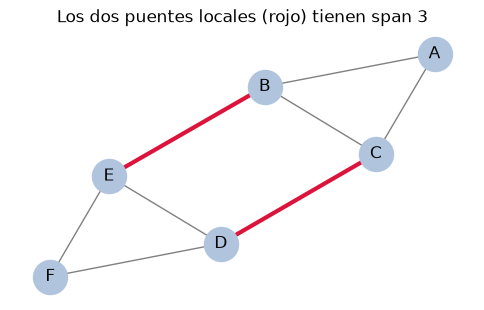

In [14]:
T = nx.Graph([("A", "B"), ("B", "C"), ("A", "C"),      # triángulo 1
              ("D", "E"), ("E", "F"), ("D", "F"),      # triángulo 2
              ("C", "D"), ("B", "E")])                 # dos conexiones entre ellos

for u, v in T.edges():
    print(f"{u}-{v}:  O = {solapamiento(T, u, v):.3f}   "
          f"puente local = {str(es_puente_local(T, u, v)):5s}  span = {span(T, u, v)}")

fig, ax = plt.subplots(figsize=(6, 3.5))
pos_T = nx.spring_layout(T, seed=3)
anchos = [3.0 if es_puente_local(T, u, v) else 1.0 for u, v in T.edges()]
cols = ["crimson" if es_puente_local(T, u, v) else "gray" for u, v in T.edges()]
nx.draw_networkx_edges(T, pos_T, width=anchos, edge_color=cols, ax=ax)
nx.draw_networkx_nodes(T, pos_T, node_color="lightsteelblue", node_size=600, ax=ax)
nx.draw_networkx_labels(T, pos_T, ax=ax)
ax.set_title("Los dos puentes locales (rojo) tienen span 3")
ax.axis("off")
plt.show()

> **Observación.** El *span* de un puente local nunca puede ser 2. Si lo fuera,
> existiría un camino $u - w - v$, o sea un vecino común $w$, lo que contradice
> $O_{uv} = 0$. Por lo tanto **el span de un puente local es siempre $\geq 3$**
> (o infinito). Es una demostración de una línea que conviene hacer en el tablero.

### Ahora en la red de estudiantes


In [15]:
df_aristas = pd.DataFrame([
    {"u": u, "v": v,
     "fuerza": G[u][v]["fuerza"], "tipo": G[u][v]["tipo"],
     "solapamiento": solapamiento(G, u, v),
     "puente_local": es_puente_local(G, u, v)}
    for u, v in G.edges()])

pl = df_aristas[df_aristas["puente_local"]]
resto = df_aristas[~df_aristas["puente_local"]]

print(f"Puentes locales: {len(pl)} de {len(df_aristas)} aristas "
      f"({len(pl)/len(df_aristas):.1%})")
print(f"Fuerza media — puentes locales : {pl['fuerza'].mean():.2f}")
print(f"Fuerza media — resto de aristas: {resto['fuerza'].mean():.2f}")
print(f"Fracción de lazos débiles entre puentes locales: {(pl['tipo']=='debil').mean():.1%}")
print(f"Fracción de lazos débiles entre las demás      : {(resto['tipo']=='debil').mean():.1%}")
print()
print("Spans observados (primeros 20 puentes locales):",
      sorted({span(G, r.u, r.v) for r in pl.head(20).itertuples()}))

Puentes locales: 77 de 152 aristas (50.7%)
Fuerza media — puentes locales : 2.12
Fuerza media — resto de aristas: 3.08
Fracción de lazos débiles entre puentes locales: 100.0%
Fracción de lazos débiles entre las demás      : 65.3%

Spans observados (primeros 20 puentes locales): [3, 4]


### La relación fuerza–solapamiento

Esta es la figura central de [EK] §3.3: la fuerza del lazo crece con el solapamiento.


        aristas  solapamiento_medio
fuerza                             
1            23               0.000
2            46               0.062
3            57               0.060
4            22               0.166
5             4               0.212

Correlación fuerza-solapamiento: 0.541


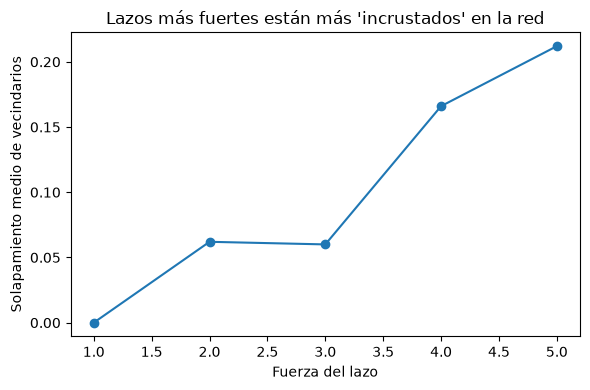

In [16]:
tabla = (df_aristas.groupby("fuerza")["solapamiento"]
         .agg(aristas="count", solapamiento_medio="mean").round(3))
print(tabla)
print(f"\nCorrelación fuerza-solapamiento: {df_aristas['fuerza'].corr(df_aristas['solapamiento']):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tabla.index, tabla["solapamiento_medio"], marker="o")
ax.set_xlabel("Fuerza del lazo")
ax.set_ylabel("Solapamiento medio de vecindarios")
ax.set_title("Lazos más fuertes están más 'incrustados' en la red")
fig.tight_layout()
plt.show()

---
# 5. La propiedad de cierre triádico fuerte

**Lectura: [EK] §3.1**

[EK] formalizan la intuición de Granovetter con una hipótesis fuerte pero limpia:

> **Propiedad de Cierre Triádico Fuerte (STC).** Un nodo $u$ satisface STC si, para
> todo par de vecinos $v, w$ conectados a $u$ por lazos **fuertes**, existe la arista
> $\{v, w\}$ (de cualquier fuerza).

Y de ahí sale un resultado sorprendentemente potente:

> **Teorema ([EK] §3.1).** Si $u$ satisface STC y tiene al menos dos lazos fuertes,
> entonces **cualquier puente local que involucre a $u$ es un lazo débil**.

**Demostración (por contradicción, una línea).** Supongamos que $\{u,v\}$ es un puente
local *y* un lazo fuerte. Como $u$ tiene al menos dos lazos fuertes, existe otro
vecino $w \neq v$ unido a $u$ por lazo fuerte. Por STC, la arista $\{v,w\}$ existe.
Pero entonces $w$ es vecino común de $u$ y $v$, luego $O_{uv} > 0$ y $\{u,v\}$ no era
puente local. Contradicción. $\blacksquare$

Verifiquémoslo numéricamente. El valor de hacerlo no es "confirmar" el teorema —está
demostrado— sino comprobar que nuestra implementación de las definiciones es correcta:
**si apareciera un contraejemplo, el error estaría en el código, no en el teorema**.


In [17]:
def viola_stc(G, u):
    """Número de pares de lazos fuertes de u que no están cerrados."""
    fuertes = [w for w in G[u] if G[u][w]["tipo"] == "fuerte"]
    return sum(1 for a, b in itertools.combinations(fuertes, 2) if not G.has_edge(a, b))


violaciones = {u: viola_stc(G, u) for u in G}
cumplen = [u for u, k in violaciones.items() if k == 0]

print(f"Nodos que satisfacen STC: {len(cumplen)} de {G.number_of_nodes()}")
print(f"Total de pares fuertes sin cerrar: {sum(violaciones.values())}")

casos = contraejemplos = 0
for u, v in G.edges():
    if not es_puente_local(G, u, v):
        continue
    for nodo, otro in [(u, v), (v, u)]:
        fuertes_n = [w for w in G[nodo] if G[nodo][w]["tipo"] == "fuerte"]
        if violaciones[nodo] == 0 and len(fuertes_n) >= 2:
            casos += 1
            if G[nodo][otro]["tipo"] == "fuerte":
                contraejemplos += 1

print(f"\nCasos que cumplen las hipótesis del teorema: {casos}")
print(f"Contraejemplos encontrados: {contraejemplos}  (debe ser 0)")

Nodos que satisfacen STC: 53 de 60
Total de pares fuertes sin cerrar: 12

Casos que cumplen las hipótesis del teorema: 14
Contraejemplos encontrados: 0  (debe ser 0)


> **Nota metodológica importante.** Si el filtro estuviera mal escrito y `casos`
> quedara en 0, reportar "cero contraejemplos" sería vacío: no habríamos probado
> nada. Verificar que la condición se evaluó al menos una vez es parte de verificar
> el resultado. Este es un hábito que vale la pena llevarse al proyecto final.

### Sensibilidad al umbral

Nuestra división fuerte/débil usa un umbral arbitrario (`fuerza >= 4`). ¿Qué tanto
depende el resultado de esa elección?


In [18]:
resultados = []
for umbral in [2, 3, 4, 5]:
    H = G.copy()
    for u, v in H.edges():
        H[u][v]["tipo"] = "fuerte" if H[u][v]["fuerza"] >= umbral else "debil"
    viol = {u: viola_stc(H, u) for u in H}
    resultados.append({
        "umbral": umbral,
        "lazos_fuertes": sum(1 for u, v in H.edges() if H[u][v]["tipo"] == "fuerte"),
        "nodos_que_cumplen_STC": sum(1 for k in viol.values() if k == 0),
        "pares_sin_cerrar": sum(viol.values()),
    })
print(pd.DataFrame(resultados).to_string(index=False))

 umbral  lazos_fuertes  nodos_que_cumplen_STC  pares_sin_cerrar
      2            129                      6               433
      3             83                     19               174
      4             26                     53                12
      5              4                     59                 2


STC es una hipótesis **exigente**: cuanto más laxo el umbral (más lazos cuentan como
fuertes), más nodos la violan. Con umbral 2 casi ningún nodo la satisface. Esto es
esperable y no invalida la teoría: [EK] la presentan explícitamente como una
idealización cuyo valor está en generar predicciones comprobables, no en describir
exactamente la realidad.


---
# 6. El experimento de Onnela: percolación por fuerza de lazo

**Lectura: [EK] §3.3**

Onnela et al. (2007) estudian una red de 4 millones de usuarios de telefonía móvil,
midiendo la fuerza de cada lazo por el tiempo total de llamada. Hacen un experimento
de **percolación**: eliminan aristas una por una, en orden creciente de fuerza
(débiles primero) o decreciente (fuertes primero), y miden cómo se desintegra la
componente gigante.

El resultado es el argumento cuantitativo a favor de Granovetter: **la red colapsa
mucho antes cuando se eliminan los lazos débiles**, porque son los que sostienen la
conectividad entre comunidades.


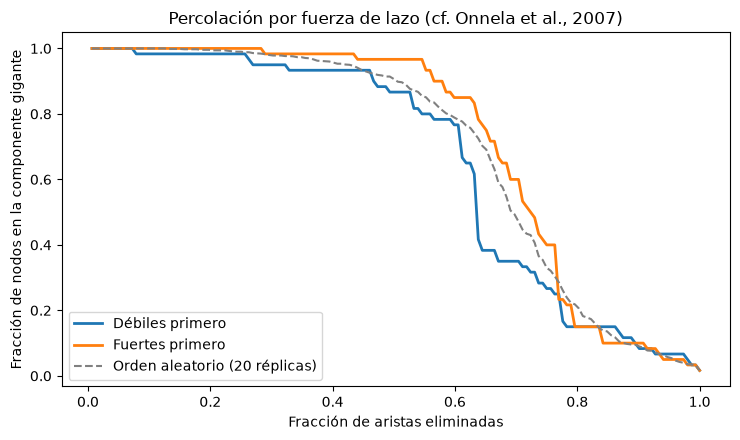

Tras eliminar el 50% de las aristas — componente gigante: débiles primero 0.867 | azar 0.907 | fuertes primero 0.967
Tras eliminar el 70% de las aristas — componente gigante: débiles primero 0.350 | azar 0.493 | fuertes primero 0.600
Tras eliminar el 80% de las aristas — componente gigante: débiles primero 0.150 | azar 0.218 | fuertes primero 0.150


In [19]:
def percolacion(G, orden):
    """Fracción de nodos en la componente gigante tras eliminar cada arista de `orden`."""
    H = G.copy()
    n = G.number_of_nodes()
    fracciones = []
    for u, v in orden:
        H.remove_edge(u, v)
        fracciones.append(len(max(nx.connected_components(H), key=len)) / n)
    return fracciones


aristas_ordenadas = sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["fuerza"])
frac_debiles = percolacion(G, aristas_ordenadas)          # débiles primero
frac_fuertes = percolacion(G, aristas_ordenadas[::-1])    # fuertes primero

# Referencia: orden aleatorio, promedio de 20 réplicas
rng_p = np.random.default_rng(SEMILLA)
replicas = []
for _ in range(20):
    orden = list(G.edges())
    rng_p.shuffle(orden)
    replicas.append(percolacion(G, orden))
frac_azar = np.mean(replicas, axis=0)

x = np.arange(1, G.number_of_edges() + 1) / G.number_of_edges()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(x, frac_debiles, label="Débiles primero", lw=2)
ax.plot(x, frac_fuertes, label="Fuertes primero", lw=2)
ax.plot(x, frac_azar, label="Orden aleatorio (20 réplicas)", ls="--", color="gray")
ax.set_xlabel("Fracción de aristas eliminadas")
ax.set_ylabel("Fracción de nodos en la componente gigante")
ax.set_title("Percolación por fuerza de lazo (cf. Onnela et al., 2007)")
ax.legend()
fig.tight_layout()
plt.show()

for q in [0.5, 0.7, 0.8]:
    k = int(q * G.number_of_edges()) - 1
    print(f"Tras eliminar el {q:.0%} de las aristas — componente gigante: "
          f"débiles primero {frac_debiles[k]:.3f} | "
          f"azar {frac_azar[k]:.3f} | fuertes primero {frac_fuertes[k]:.3f}")

La curva de "débiles primero" cae por debajo de las otras dos, y el orden aleatorio
queda en el medio: exactamente el patrón de Onnela.

### Sobre la circularidad de este ejercicio — leer con cuidado

Aquí hay que ser honestos sobre el diseño. En la sección 0 **construimos** la fuerza
como función creciente del número de vecinos comunes. Que después "descubramos" que
los puentes locales son débiles es, en parte, una tautología: lo impusimos nosotros.

¿Entonces el ejercicio no vale nada? No exactamente. Conviene separar tres cosas:

1. **La correlación fuerza–solapamiento es circular.** La impusimos en la generación.
   Este ejercicio no aporta ninguna evidencia sobre ella.
2. **La consecuencia macroscópica no es automática.** Que la componente gigante se
   desintegre más rápido al remover lazos débiles no se sigue mecánicamente de la
   definición local: depende de cómo se organizan globalmente los lazos de bajo
   solapamiento, que es una propiedad de la estructura de comunidades del SBM. Uno
   podría imponer la misma correlación local y no obtener este resultado.
3. **El aporte de Onnela es empírico y es de otra naturaleza.** Ellos miden la fuerza
   por **duración de llamadas** — una variable de comportamiento, independiente de la
   estructura de la red. Que ahí aparezca la misma correlación convierte lo que aquí
   es una definición en un **hallazgo**.

**La moraleja general:** una simulación puede mostrar que un mecanismo es *suficiente*
para producir un patrón; nunca puede mostrar que ese mecanismo es el que opera en el
mundo. Para eso hace falta que la variable explicativa se mida de forma independiente
del fenómeno que quiere explicar. Es un criterio que conviene aplicar al leer
artículos y al diseñar el proyecto final.


---
# 7. Homofilia y su *benchmark* aleatorio

**Lectura: [EK] §4.1–4.2**

La **homofilia** es la tendencia a relacionarse con quienes se nos parecen. Medirla
requiere un punto de comparación: en una población donde el 90% son economistas, la
mayoría de las amistades serán entre economistas *aunque las amistades se formen al
azar*.

El *benchmark* correcto es la mezcla aleatoria. Si un atributo toma $K$ valores con
fracciones poblacionales $p_1,\dots,p_K$, la probabilidad de que una arista
cualquiera sea **cruzada** bajo formación aleatoria es

$$\mathbb{E}[\text{fracción cruzada}] = 1 - \sum_{k=1}^{K} p_k^2$$

el complemento del índice de Simpson. Para $K = 2$ esto se reduce a la fórmula
familiar de [EK]: $1 - p^2 - q^2 = 2pq$.

**Criterio:** fracción cruzada observada **menor** que la esperada ⟹ evidencia de
homofilia. Mayor ⟹ heterofilia.


In [20]:
def test_homofilia(G, atributo):
    """Test de homofilia de EK cap. 4, generalizado a K categorías."""
    valores = pd.Series([G.nodes[v][atributo] for v in G.nodes()])
    p = valores.value_counts(normalize=True)
    esperado = 1 - float((p ** 2).sum())
    m = G.number_of_edges()
    cruzadas = sum(1 for u, v in G.edges()
                   if G.nodes[u][atributo] != G.nodes[v][atributo])
    observado = cruzadas / m if m else 0.0
    return {"proporciones": p.to_dict(), "esperado": esperado,
            "observado": observado, "homofilia": bool(observado < esperado)}


for atributo in ["programa", "ciudad"]:
    r = test_homofilia(G, atributo)
    K = len(r["proporciones"])
    print(f"--- {atributo}  (K = {K}) ---")
    print("   proporciones:", {k: round(v, 3) for k, v in r["proporciones"].items()})
    print(f"   esperado bajo mezcla aleatoria: {r['esperado']:.4f}")
    print(f"   observado                     : {r['observado']:.4f}")
    print(f"   ¿homofilia?                   : {r['homofilia']}")
    print()

# Verificación de que con K=2 la fórmula se reduce a 2pq
pp = list(test_homofilia(G, "programa")["proporciones"].values())
print(f"Comprobación K=2:  1 - sum(p_k^2) = {1 - sum(x**2 for x in pp):.6f}"
      f"   vs.   2pq = {2*pp[0]*pp[1]:.6f}")

--- programa  (K = 2) ---
   proporciones: {'Economía': 0.583, 'Ingeniería': 0.417}
   esperado bajo mezcla aleatoria: 0.4861
   observado                     : 0.0987
   ¿homofilia?                   : True

--- ciudad  (K = 4) ---
   proporciones: {'Bogotá': 0.6, 'Cali': 0.217, 'Medellín': 0.15, 'Barranquilla': 0.033}
   esperado bajo mezcla aleatoria: 0.5694
   observado                     : 0.6053
   ¿homofilia?                   : False

Comprobación K=2:  1 - sum(p_k^2) = 0.486111   vs.   2pq = 0.486111


**Dos resultados muy distintos.**

- `programa`: observado 0.099 contra esperado 0.486. Homofilia **masiva** — y es la
  respuesta correcta, porque el SBM la construyó así por diseño.
- `ciudad`: observado 0.605 contra esperado 0.569. Ligeramente *por encima*, es decir
  heterofilia aparente. Pero la ciudad se asignó de forma **independiente** de la
  estructura: aquí no hay ningún mecanismo, solo ruido muestral.

Esto ilustra un punto metodológico central: el test da un número siempre, y la
diferencia observado–esperado no viene con una medida de incertidumbre. Con 152
aristas, una desviación de 0.036 es perfectamente compatible con el azar. Un test
serio necesita una **distribución nula**, que podemos construir por permutación:
reasignamos las etiquetas al azar entre los nodos, manteniendo la estructura de la
red fija, y vemos dónde cae el valor observado.


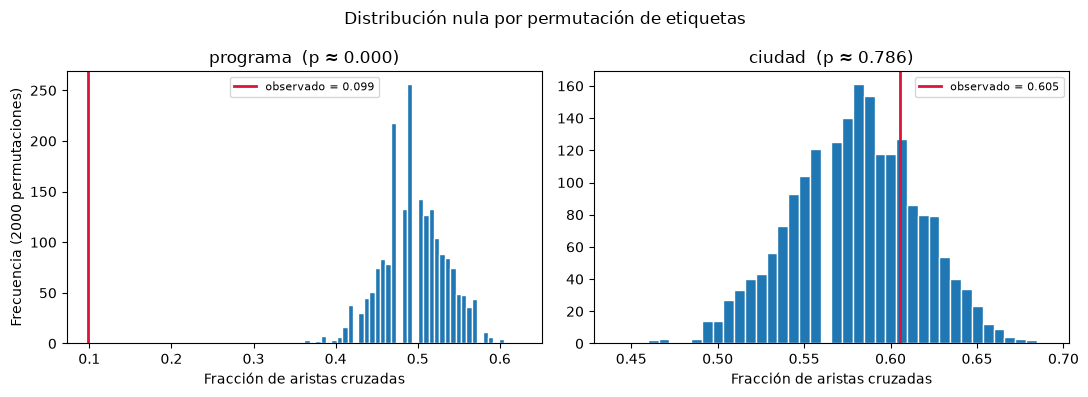

In [21]:
def nula_por_permutacion(G, atributo, reps=2000, semilla=SEMILLA):
    """Distribución de la fracción cruzada bajo permutación aleatoria de etiquetas."""
    rng_perm = np.random.default_rng(semilla)
    etiquetas = np.array([G.nodes[v][atributo] for v in sorted(G.nodes())])
    aristas = list(G.edges())
    out = np.empty(reps)
    for r in range(reps):
        perm = rng_perm.permutation(etiquetas)
        out[r] = np.mean([perm[u] != perm[v] for u, v in aristas])
    return out


fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for eje, atributo in zip(ax, ["programa", "ciudad"]):
    nula = nula_por_permutacion(G, atributo)
    obs = test_homofilia(G, atributo)["observado"]
    p_val = np.mean(nula <= obs)
    eje.hist(nula, bins=40, edgecolor="white")
    eje.axvline(obs, color="crimson", lw=2, label=f"observado = {obs:.3f}")
    eje.set_title(f"{atributo}  (p ≈ {p_val:.3f})")
    eje.set_xlabel("Fracción de aristas cruzadas")
    eje.legend(fontsize=8)
ax[0].set_ylabel("Frecuencia (2000 permutaciones)")
fig.suptitle("Distribución nula por permutación de etiquetas")
fig.tight_layout()
plt.show()

Con la distribución nula el panorama se aclara: para `programa` el valor observado
queda completamente fuera del rango del azar; para `ciudad` cae cómodamente dentro.
El test de $2pq$ da la intuición correcta, pero **la permutación es la que permite
afirmar algo**.

### Selección o influencia: el problema de identificación

[EK] §4.1 señala que la homofilia observada puede venir de dos mecanismos opuestos:

- **Selección**: elijo amigos que ya se me parecen.
- **Influencia social** (socialización): me vuelvo parecido a mis amigos.

Una sola fotografía de la red **no puede distinguirlos**: ambos producen exactamente
la misma correlación entre atributo y adyacencia. Se necesitan datos **longitudinales**
—ver qué cambia primero, el lazo o el atributo— y aun así la inferencia causal es
delicada. Para `programa` sabemos que es selección (nadie cambia de carrera por sus
amigos, al menos no en nuestro modelo); en aplicaciones reales —obesidad, tabaquismo,
comportamiento electoral— la distinción es exactamente lo que está en disputa.


---
# 8. Redes de afiliación y cierre focal

**Lectura: [EK] §4.3**

Las personas no se conectan en el vacío: comparten **contextos** (cursos, empresas,
barrios, clubes). [EK] modelan esto con una **red de afiliación**, un grafo
**bipartito** con personas de un lado y focos de actividad del otro.

Esto da lugar a tres tipos de cierre:

| Cierre | Mecanismo |
|---|---|
| **Triádico** | Dos personas con un amigo común se hacen amigas |
| **Focal** | Dos personas en un mismo foco se hacen amigas |
| **Por membresía** | Una persona se une al foco de un amigo |

Construyamos una red de afiliación estudiante–curso.


In [22]:
rng_af = np.random.default_rng(SEMILLA + 1)
CURSOS = ["Microeconomía", "Macroeconomía", "Econometría I", "Econometría II",
          "Redes Sociales", "Machine Learning", "Teoría de Juegos",
          "Historia Económica", "Economía Pública", "Organización Industrial",
          "Economía Laboral", "Métodos Computacionales"]

inscripciones = []
for i in range(60):
    k = rng_af.integers(2, 4)
    inscripciones += [(i, c) for c in rng_af.choice(CURSOS, size=k, replace=False)]

B = nx.Graph()
B.add_nodes_from(range(60), bipartite=0)
B.add_nodes_from(CURSOS, bipartite=1)
B.add_edges_from(inscripciones)

print("¿Es bipartito?", nx.is_bipartite(B))
print(f"{len(inscripciones)} inscripciones | "
      f"{B.number_of_nodes()} nodos ({60} estudiantes + {len(CURSOS)} cursos)")
print("\nTamaño de cada curso:")
print(pd.Series({c: B.degree(c) for c in CURSOS}).sort_values(ascending=False).to_string())

¿Es bipartito? True
148 inscripciones | 72 nodos (60 estudiantes + 12 cursos)

Tamaño de cada curso:
Microeconomía              17
Econometría II             16
Historia Económica         16
Teoría de Juegos           14
Métodos Computacionales    14
Econometría I              13
Redes Sociales             13
Macroeconomía              11
Machine Learning           11
Organización Industrial     9
Economía Laboral            8
Economía Pública            6


### La proyección

Para pasar de la red bipartita a una red persona–persona se hace una **proyección**:
dos estudiantes quedan conectados si comparten al menos un curso, con peso igual al
número de cursos compartidos.

La proyección tiene una propiedad que hay que conocer: **infla artificialmente el
clustering**. La razón es geométrica: un curso con $k$ inscritos genera un **clique**
completo de $k$ nodos en la proyección, y los cliques tienen clustering 1. Un
clustering alto en una red proyectada **no es evidencia de cierre triádico**; es un
artefacto de la proyección.


In [23]:
P = nx.bipartite.weighted_projected_graph(B, range(60))

comparacion = pd.DataFrame([
    {"red": "Amistad (G)", "aristas": G.number_of_edges(),
     "densidad": nx.density(G), "clustering_global": nx.transitivity(G)},
    {"red": "Afiliación proyectada (P)", "aristas": P.number_of_edges(),
     "densidad": nx.density(P), "clustering_global": nx.transitivity(P)},
]).round(4)
print(comparacion.to_string(index=False))

print(f"\nEl curso más grande tiene {max(B.degree(c) for c in CURSOS)} inscritos,")
print("lo que por sí solo genera un clique de ese tamaño en la proyección.")

                      red  aristas  densidad  clustering_global
              Amistad (G)      152    0.0859             0.1320
Afiliación proyectada (P)      800    0.4520             0.6056

El curso más grande tiene 17 inscritos,
lo que por sí solo genera un clique de ese tamaño en la proyección.


### ¿Explica la afiliación la amistad?

Pregunta natural: ¿los amigos tienden a compartir cursos más de lo que cabría esperar
por azar? El *benchmark* correcto es la densidad de `P` — la probabilidad de que dos
estudiantes cualesquiera compartan curso.


In [24]:
compartidas = sum(1 for u, v in G.edges() if P.has_edge(u, v))
frac_obs = compartidas / G.number_of_edges()

print(f"Amistades que comparten al menos un curso: {compartidas}/{G.number_of_edges()}"
      f" = {frac_obs:.4f}")
print(f"Esperado si amistad y afiliación fueran independientes: {nx.density(P):.4f}")
print(f"Razón observado/esperado: {frac_obs / nx.density(P):.3f}")

Amistades que comparten al menos un curso: 72/152 = 0.4737
Esperado si amistad y afiliación fueran independientes: 0.4520
Razón observado/esperado: 1.048


La razón es ≈ 1.05: prácticamente no hay asociación. Y **eso es lo correcto en esta
red**, porque generamos las inscripciones de forma independiente de la estructura de
amistad. El ejercicio sirve como control negativo: nuestro procedimiento no inventa
señal donde no la hay.

En datos reales uno esperaría una razón claramente mayor que 1, por los mecanismos de
cierre focal y por membresía. Distinguir entre esos dos —¿los cursos generan
amistades, o las amistades generan matrículas conjuntas?— es, otra vez, un problema
que exige datos en dos momentos del tiempo.

> **Para discutir en clase.** ¿Cómo modificarían la generación de `inscripciones`
> para producir cierre focal genuino? ¿Y cierre por membresía? ¿Qué diferencia
> observable habría entre las dos redes resultantes?


---
# 9. Balance estructural

**Lectura: [EK] §5.1–5.3**

Hasta aquí todas las relaciones eran positivas. [EK] cap. 5 introduce redes con
**signo**: $+1$ para amistad/alianza, $-1$ para enemistad/conflicto.

En un grafo **completo con signo**, un triángulo es **balanceado** si es de uno de
estos dos tipos:

- **+ + +** — "tres amigos mutuos".
- **+ − −** — "el enemigo de mi enemigo es mi amigo": dos aliados con un enemigo común.

Y es **desbalanceado** si es de los otros dos:

- **+ + −** — dos amigos míos que se detestan (tensión psicológica).
- **− − −** — tres enemigos mutuos (dos de ellos tienen incentivo a aliarse).

Criterio operativo: **el triángulo es balanceado si el producto de sus tres signos es
positivo**.


In [25]:
def clasificar_triangulos(S):
    """(balanceados, desbalanceados) sobre todos los triángulos de un grafo con signo."""
    bal = desbal = 0
    for t in itertools.combinations(S.nodes(), 3):
        pares = list(itertools.combinations(t, 2))
        if not all(S.has_edge(x, y) for x, y in pares):
            continue
        producto = 1
        for x, y in pares:
            producto *= S[x][y]["signo"]
        if producto > 0:
            bal += 1
        else:
            desbal += 1
    return bal, desbal


# Los cuatro tipos de triángulo, uno por uno
for signos, nombre in [((1, 1, 1), "+ + +"), ((1, -1, -1), "+ - -"),
                       ((1, 1, -1), "+ + -"), ((-1, -1, -1), "- - -")]:
    tri = nx.Graph()
    for (x, y), s in zip([("a", "b"), ("b", "c"), ("a", "c")], signos):
        tri.add_edge(x, y, signo=s)
    b, dsb = clasificar_triangulos(tri)
    print(f"{nombre}  ->  {'BALANCEADO' if b else 'DESBALANCEADO'}"
          f"   (producto = {np.prod(signos):+d})")

+ + +  ->  BALANCEADO   (producto = +1)
+ - -  ->  BALANCEADO   (producto = +1)
+ + -  ->  DESBALANCEADO   (producto = -1)
- - -  ->  DESBALANCEADO   (producto = -1)


### El teorema del balance

> **Teorema (Cartwright–Harary).** Si en un grafo **completo** con signo *todos* los
> triángulos son balanceados, entonces los nodos pueden partirse en **a lo sumo dos**
> conjuntos, de modo que todas las relaciones **dentro** de cada conjunto son
> positivas y todas las relaciones **entre** conjuntos son negativas.

Lo notable del enunciado es el salto de escala: una condición puramente **local**
(sobre triángulos) determina la estructura **global** de toda la red. No hay estados
intermedios — o hay dos facciones, o hay al menos un triángulo desbalanceado.

Construyamos un ejemplo: nueve países, dos bloques.


In [26]:
PAISES = list("ABCDEFGHI")
faccion_real = {p: (0 if k < 5 else 1) for k, p in enumerate(PAISES)}

S_bal = nx.Graph()
for a, b in itertools.combinations(PAISES, 2):
    S_bal.add_edge(a, b, signo=1 if faccion_real[a] == faccion_real[b] else -1)

# La misma red con tres signos invertidos
S_pert = S_bal.copy()
for a, b in [("A", "B"), ("C", "G"), ("E", "F")]:
    S_pert[a][b]["signo"] *= -1

print("S_bal  (balanceados, desbalanceados) =", clasificar_triangulos(S_bal))
print("S_pert (balanceados, desbalanceados) =", clasificar_triangulos(S_pert))
print("\nInvertir 3 de 36 signos (8%) desbalancea 21 de 84 triángulos (25%).")

S_bal  (balanceados, desbalanceados) = (84, 0)
S_pert (balanceados, desbalanceados) = (63, 21)

Invertir 3 de 36 signos (8%) desbalancea 21 de 84 triángulos (25%).


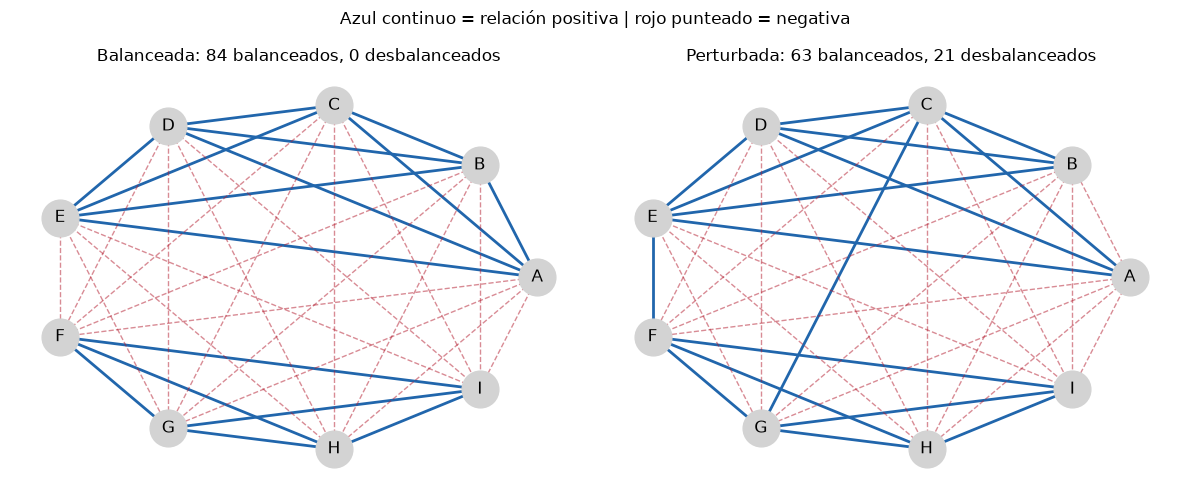

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pos_S = nx.circular_layout(S_bal)

for eje, (Red, titulo) in zip(axes, [(S_bal, "Balanceada"), (S_pert, "Perturbada")]):
    pos_e = [(u, v) for u, v in Red.edges() if Red[u][v]["signo"] > 0]
    neg_e = [(u, v) for u, v in Red.edges() if Red[u][v]["signo"] < 0]
    nx.draw_networkx_edges(Red, pos_S, edgelist=pos_e, edge_color="#2166ac",
                           width=2, ax=eje)
    nx.draw_networkx_edges(Red, pos_S, edgelist=neg_e, edge_color="#b2182b",
                           style="dashed", alpha=0.5, ax=eje)
    nx.draw_networkx_nodes(Red, pos_S, node_color="lightgray", node_size=700, ax=eje)
    nx.draw_networkx_labels(Red, pos_S, ax=eje)
    b, dsb = clasificar_triangulos(Red)
    eje.set_title(f"{titulo}: {b} balanceados, {dsb} desbalanceados")
    eje.axis("off")

fig.suptitle("Azul continuo = relación positiva | rojo punteado = negativa")
fig.tight_layout()
plt.show()

### Recuperar las facciones con un recorrido local

La demostración del teorema es constructiva y se traduce directamente en un
algoritmo: recorremos el grafo con **BFS**, asignando etiquetas 0/1. Al cruzar una
arista positiva la etiqueta se mantiene; al cruzar una negativa, se invierte. Si en
algún momento llegamos a un nodo por dos caminos que exigen etiquetas distintas, hay
contradicción y la red no es balanceada.

Es el mismo BFS de la clase anterior, con una regla de propagación de signo. Nótese
que el algoritmo **nunca mira un triángulo**: solo mira una arista a la vez. Que aun
así produzca la partición global *es* el contenido del teorema.


In [28]:
def particion_facciones(S):
    """Etiquetas {0,1} compatibles con los signos, o None si la red no es balanceada."""
    etiqueta = {}
    for inicio in S.nodes():
        if inicio in etiqueta:
            continue
        etiqueta[inicio] = 0
        cola = deque([inicio])
        while cola:
            u = cola.popleft()
            for v in S[u]:
                esperada = etiqueta[u] if S[u][v]["signo"] > 0 else 1 - etiqueta[u]
                if v not in etiqueta:
                    etiqueta[v] = esperada
                    cola.append(v)
                elif etiqueta[v] != esperada:
                    return None          # contradicción: no es balanceada
    return etiqueta


part = particion_facciones(S_bal)
grupos = {}
for nodo, lab in part.items():
    grupos.setdefault(lab, []).append(nodo)

print("S_bal  -> facciones recuperadas:", {k: sorted(v) for k, v in grupos.items()})
print("S_pert ->", particion_facciones(S_pert))
print("\nLa partición coincide con la que usamos para construir la red:",
      {k: sorted(v) for k, v in grupos.items()} ==
      {0: list("ABCDE"), 1: list("FGHI")})

S_bal  -> facciones recuperadas: {0: ['A', 'B', 'C', 'D', 'E'], 1: ['F', 'G', 'H', 'I']}
S_pert -> None

La partición coincide con la que usamos para construir la red: True


> **Observación.** La partición es única *salvo intercambio de etiquetas*: llamar
> "facción 0" a un grupo o al otro es arbitrario. Esto es análogo a la
> 2-coloreabilidad de un grafo bipartito, y no es coincidencia: el algoritmo es
> esencialmente el mismo.

### Qué se rompe si el grafo no es completo

El teorema exige que **todos** los pares estén relacionados. En grafos incompletos la
noción correcta es distinta: una red con signo es balanceada si y solo si **todo ciclo
tiene un número par de aristas negativas**. Nuestro algoritmo BFS de hecho verifica
esta condición más general (por eso funciona sin mirar triángulos), pero el enunciado
"dos facciones" ya no se sigue de "todos los triángulos balanceados".


In [29]:
# Ciclo de longitud 4 con exactamente un signo negativo: sin triángulos,
# pero desbalanceado en el sentido de ciclos.
C4 = nx.Graph()
C4.add_edge("p", "q", signo=1)
C4.add_edge("q", "r", signo=1)
C4.add_edge("r", "s", signo=1)
C4.add_edge("s", "p", signo=-1)

print("Triángulos:", clasificar_triangulos(C4), " <- no hay ninguno que clasificar")
print("particion_facciones:", particion_facciones(C4), " <- detecta el desbalance igual")

Triángulos: (0, 0)  <- no hay ninguno que clasificar
particion_facciones: None  <- detecta el desbalance igual


El criterio de triángulos no ve nada porque no hay triángulos; el criterio de ciclos
sí detecta el problema. Esta es la razón por la que la literatura posterior trabaja
con la caracterización por ciclos.

> **Para discutir en clase.** [EK] §5.5 discute el **balance débil**, que permite
> el triángulo $- - -$ y admite **más de dos** facciones. ¿Qué situación
> internacional describe mejor ese relajamiento?


---
# 10. Síntesis

Cuatro ideas para llevarse de esta sesión:

**1. La medición no es neutral.** Clustering global vs. promedio, grado vs.
intermediación vs. Bonacich: la elección de medida incorpora un supuesto sobre qué
proceso importa. El parámetro $a$ de Bonacich es el caso más explícito — dice qué tan
lejos viajan los efectos que uno cree relevantes.

**2. Todo número necesita un *benchmark*.** Clustering 0.13 no significa nada solo;
significa algo contra la densidad 0.086 y contra el 0.066 de un $G(n,m)$. Fracción
cruzada 0.099 no significa nada solo; significa algo contra $1-\sum p_k^2 = 0.486$ y,
mejor aún, contra una distribución de permutación.

**3. La estructura local determina la estructura global.** Es el hilo conductor de
[EK] cap. 3 y 5: el cierre triádico fuerte fuerza que los puentes sean débiles; el
balance de triángulos fuerza la partición en dos facciones. En ambos casos una
condición sobre tríos de nodos tiene consecuencias sobre la red entera.

**4. Simular no es identificar.** Nuestro ejercicio de percolación reprodujo el
patrón de Onnela porque lo construimos así. Una simulación demuestra suficiencia de
un mecanismo, nunca su operación en el mundo. La distinción selección/influencia y la
distinción cierre focal/por membresía son la misma dificultad con otro nombre: una
foto estática no identifica un proceso dinámico.

## Hacia dónde sigue

- **Semana 34–35, mercados e interacciones estratégicas** ([EK] cap. 10–12): la
  estructura de la red pasa de ser el objeto de medición a ser la restricción sobre la
  que se juega un juego.
- **Proyecto final:** los criterios de esta clase —¿contra qué comparo?, ¿mi variable
  explicativa se mide independientemente del fenómeno?— son exactamente los que se
  evalúan en la propuesta.

## Referencias

- Jackson, M. (2018). *Social and Economic Networks*, cap. 2.
- Easley, D. y Kleinberg, J. (2010). *Networks, Crowds and Markets*, cap. 3, 4 y 5.
- Granovetter, M. (1973). The Strength of Weak Ties. *American Journal of Sociology*, 78(6).
- Onnela, J.-P. et al. (2007). Structure and tie strengths in mobile communication
  networks. *PNAS*, 104(18).
- Cartwright, D. y Harary, F. (1956). Structural balance: a generalization of Heider's
  theory. *Psychological Review*, 63(5).
